In [1]:
!pip install xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

print('All imports done!')

All imports done!


In [2]:
full_data = pd.read_csv(r"C:\Users\honey\Downloads\Copy of UNSW_NB15_training-set.csv")

print('Total rows:', len(full_data))
full_data = full_data.dropna(subset=['label'])

le_y = LabelEncoder()
full_data['label'] = le_y.fit_transform(full_data['label'])

train, test = train_test_split(
    full_data, test_size=0.3, random_state=42, stratify=full_data['label']
)

print('Train label distribution:')
print(train['label'].value_counts())
print('\nTest label distribution:')
print(test['label'].value_counts())

Total rows: 175341
Train label distribution:
label
1    83538
0    39200
Name: count, dtype: int64

Test label distribution:
label
1    35803
0    16800
Name: count, dtype: int64


In [3]:
# STEP 3: Data Cleaning aur Shuffling
print("3. DATA CLEANING  ")

# 1. remove Nan values 
train = train.dropna(subset=['label']) 
test = test.dropna(subset=['label'])

# 2.start shuffling the data (so that model would not learn any order or pattern from the data)

train = train.sample(frac=1, random_state=42).reset_index(drop=True) 
test = test.sample(frac=1, random_state=42).reset_index(drop=True)

# 3. Creating X and Y (So that the mixed data going to contain in this )
X_train = train.drop(['id', 'attack_cat', 'label'], axis=1)
y_train = train['label']

X_test = test.drop(['id', 'attack_cat', 'label'], axis=1)
y_test = test['label']

print("Data is ready    !")

3. DATA CLEANING  
Data is ready    !


In [4]:
# STEP 4 — Encode Categorical Columns (robust version)

# Force-convert ALL object columns, including any hidden ones
for col in X_train.select_dtypes(include=['object']).columns.tolist():
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_test[col]])
    le.fit(combined)
    X_train[col] = le.transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])

# Safety check — ensure NO string columns remain
remaining = X_train.select_dtypes(include=['object']).columns.tolist()
if remaining:
    print(f'WARNING: Still has string columns: {remaining}')
else:
    print('All columns are numeric. Safe to proceed.')

print(X_train.dtypes.value_counts())

All columns are numeric. Safe to proceed.
int64      31
float64    11
Name: count, dtype: int64


In [5]:
print("4. Training Random Forest model...")
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest trained   !")

4. Training Random Forest model...
Random Forest trained   !


In [6]:
# STEP 5: XGBoost Calculation
print("5. Training XGBoost model...")
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGBoost trained!")

5. Training XGBoost model...
XGBoost trained!


In [7]:
# DIAGNOSIS CELL - Pehle ye run karo
print("y_train class distribution:")
print(y_train.value_counts())
print(f"\nTotal samples: {len(y_train)}")
print(f"Unique classes: {y_train.unique()}")

print("\ny_test class distribution:")
print(y_test.value_counts())

y_train class distribution:
label
1    83538
0    39200
Name: count, dtype: int64

Total samples: 122738
Unique classes: [1 0]

y_test class distribution:
label
1    35803
0    16800
Name: count, dtype: int64


In [8]:
import numpy as np
print("y_train class distribution:", np.unique(y_train, return_counts=True))
print("y_test class distribution:", np.unique(y_test, return_counts=True))

y_train class distribution: (array([0, 1]), array([39200, 83538]))
y_test class distribution: (array([0, 1]), array([16800, 35803]))


In [9]:
print("y_train unique values:", y_train.unique())
print("y_train value counts:")
print(y_train.value_counts())
print("\nfull_data label counts:")
print(full_data['label'].value_counts())

y_train unique values: [1 0]
y_train value counts:
label
1    83538
0    39200
Name: count, dtype: int64

full_data label counts:
label
1    119341
0     56000
Name: count, dtype: int64


In [10]:
print(full_data.columns.tolist())
print(full_data.head(3))

['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']
   id       dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0   1  0.121478   tcp       -   FIN      6      4     258     172  74.087490   
1   2  0.649902   tcp       -   FIN     14     38     734   42014  78.473372   
2   3  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   

   ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  \
0  ...                 1               1             0           0   
1  ...                

In [11]:
# STEP 7: Stacking Classifier
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

# Fix class imbalance
print("Before SMOTE:", y_train.value_counts().to_dict())
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print("After SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())

# Stacking on balanced data
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

estimators = [
    ('rf',  RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1))
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=skf
)

stacking.fit(X_train_bal, y_train_bal)
stack_pred = stacking.predict(X_test)
print('Stacking done!')

Before SMOTE: {1: 83538, 0: 39200}
After SMOTE: {1: 83538, 0: 83538}
Stacking done!


In [12]:
print("7. Results \n")

models = {
    "Random Forest": rf_pred,
    "XGBoost":       xgb_pred,
    "Stacking":      stack_pred
}

for name, pred in models.items():
    print(f"--- {name} ---")
    print(f"  Accuracy  : {accuracy_score(y_test, pred):.4f}")
    print(f"  Precision : {precision_score(y_test, pred):.4f}")
    print(f"  Recall    : {recall_score(y_test, pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_test, pred):.4f}")
    print()

7. Results 

--- Random Forest ---
  Accuracy  : 0.9590
  Precision : 0.9638
  Recall    : 0.9764
  F1 Score  : 0.9701

--- XGBoost ---
  Accuracy  : 0.9578
  Precision : 0.9636
  Recall    : 0.9748
  F1 Score  : 0.9692

--- Stacking ---
  Accuracy  : 0.9563
  Precision : 0.9718
  Recall    : 0.9638
  F1 Score  : 0.9678



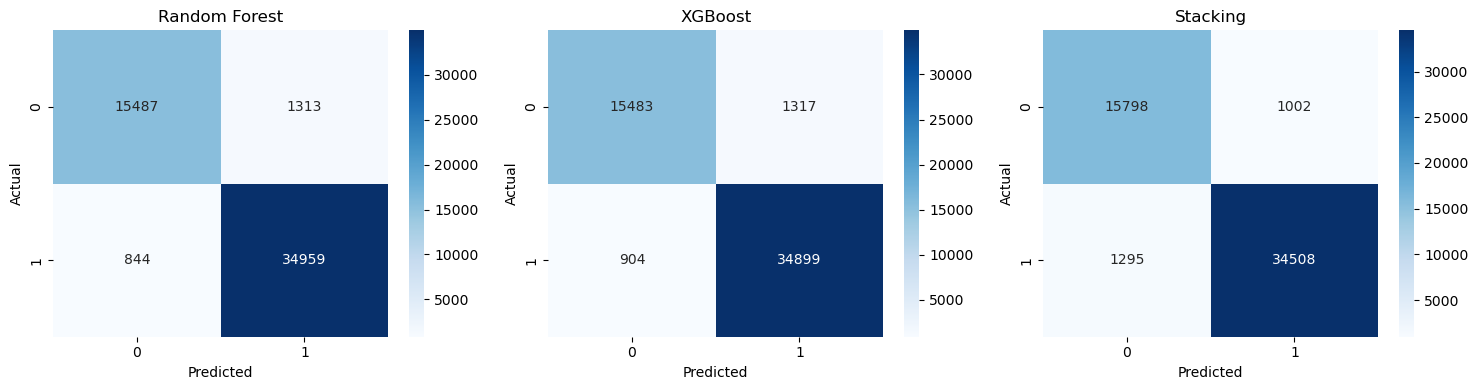

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()


In [14]:
# This is a Hybrid Model (RF for feature selection → XGBoost for classification). 
import numpy as np

# RF ki feature importance se top features lo
rf_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = rf_imp.sort_values(ascending=False).head(20).index.tolist()

print("Top 20 Features Selected by RF:")
print(top_features)

# FEATURE SELECTION 
X_train_selected = X_train[top_features]
X_test_selected  = X_test[top_features]

# TRAINING OF XGBOOST
xgb_hybrid = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_hybrid.fit(X_train_selected, y_train)
xgb_hybrid_pred = xgb_hybrid.predict(X_test_selected)

# Results
print("\n--- Hybrid Model (RF + XGBoost) ---")
print(f"  Accuracy  : {accuracy_score(y_test, xgb_hybrid_pred):.4f}")
print(f"  Precision : {precision_score(y_test, xgb_hybrid_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, xgb_hybrid_pred):.4f}")
print(f"  F1 Score  : {f1_score(y_test, xgb_hybrid_pred):.4f}")

Top 20 Features Selected by RF:
['ct_state_ttl', 'sttl', 'dload', 'rate', 'sload', 'dttl', 'synack', 'ackdat', 'tcprtt', 'dmean', 'smean', 'ct_srv_dst', 'sbytes', 'ct_dst_src_ltm', 'ct_srv_src', 'sinpkt', 'dur', 'ct_dst_sport_ltm', 'dbytes', 'dloss']

--- Hybrid Model (RF + XGBoost) ---
  Accuracy  : 0.9553
  Precision : 0.9597
  Recall    : 0.9753
  F1 Score  : 0.9674


In [15]:
TESTING = pd.read_csv(r"C:\Users\honey\Downloads\UNSW_NB15_testing-set.csv")
print ("Testing set shape :",TESTING.shape)
print("label distribution in testing set :")
print(TESTING['label'].value_counts())

Testing set shape : (82332, 45)
label distribution in testing set :
label
1    45332
0    37000
Name: count, dtype: int64


In [16]:
TESTING = TESTING.dropna(subset=['label'])

y_final_test = TESTING['label']
X_final_test = TESTING.drop(['id', 'attack_cat', 'label'], axis=1)

# Encode categorical columns consistently with training
for col in X_final_test.select_dtypes(include=['object']).columns.tolist():
    le_col = LabelEncoder()
    combined = pd.concat([full_data[col].astype(str), X_final_test[col].astype(str)])
    le_col.fit(combined)
    X_final_test[col] = le_col.transform(X_final_test[col].astype(str))

print("X_final_test shape:", X_final_test.shape)
print("Remaining object cols:", X_final_test.select_dtypes(include=['object']).columns.tolist())

X_final_test shape: (82332, 42)
Remaining object cols: []


In [17]:
X_final_test_selected = X_final_test[top_features]

final_models = {
    'Random Forest'       : (rf,         X_final_test),
    'XGBoost'             : (xgb,        X_final_test),
    'Stacking'            : (stacking,   X_final_test),
    'Hybrid (RF+XGBoost)' : (xgb_hybrid, X_final_test_selected),
}

print('=' * 55)
print('   RESULTS ON OFFICIAL UNSW-NB15 TEST SET')
print('=' * 55)

final_preds = {}
for name, (model, X_inp) in final_models.items():
    pred = model.predict(X_inp)
    final_preds[name] = pred
    print(f"\n--- {name} ---")
    print(f"  Accuracy  : {accuracy_score(y_final_test, pred):.4f}")
    print(f"  Precision : {precision_score(y_final_test, pred):.4f}")
    print(f"  Recall    : {recall_score(y_final_test, pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_final_test, pred):.4f}")

   RESULTS ON OFFICIAL UNSW-NB15 TEST SET

--- Random Forest ---
  Accuracy  : 0.8744
  Precision : 0.8221
  Recall    : 0.9850
  F1 Score  : 0.8962

--- XGBoost ---
  Accuracy  : 0.8741
  Precision : 0.8241
  Recall    : 0.9806
  F1 Score  : 0.8956

--- Stacking ---
  Accuracy  : 0.8898
  Precision : 0.8488
  Recall    : 0.9733
  F1 Score  : 0.9068

--- Hybrid (RF+XGBoost) ---
  Accuracy  : 0.8707
  Precision : 0.8220
  Recall    : 0.9767
  F1 Score  : 0.8927


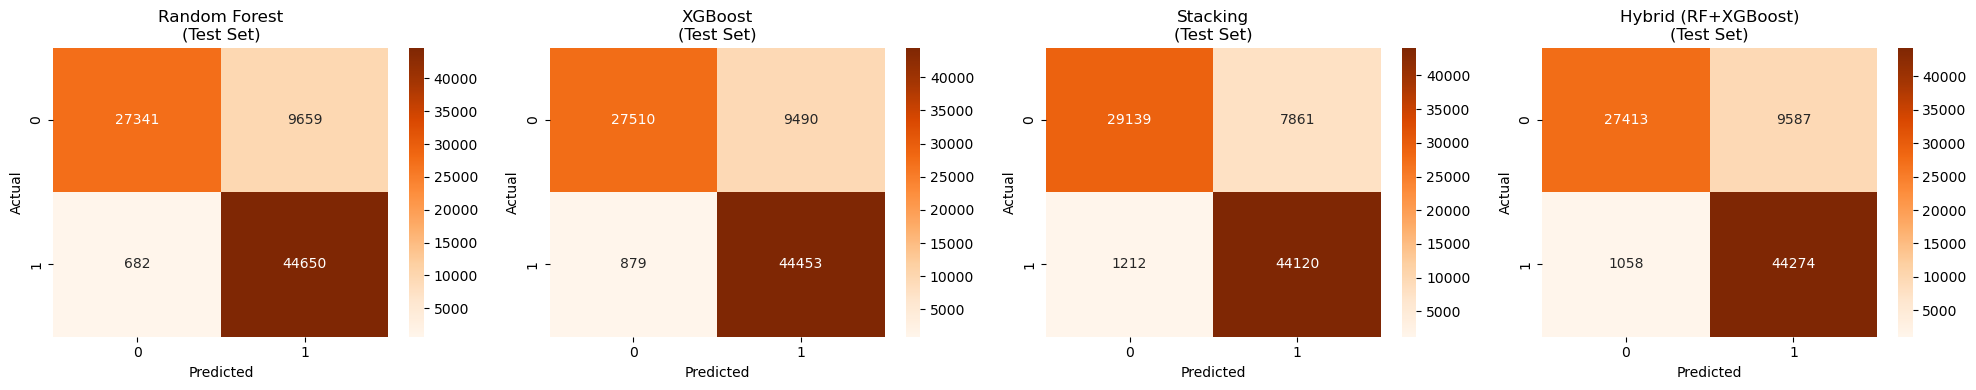

Saved: confusion_matrices_test_set.png


In [18]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, pred) in zip(axes, final_preds.items()):
    cm = confusion_matrix(y_final_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax)
    ax.set_title(f"{name}\n(Test Set)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices_test_set.png", dpi=150)
plt.show()
print("Saved: confusion_matrices_test_set.png")